In [2]:
import torch
import pyvips as Vips
import numpy as np
from Reinhard import Reinhard
import cv2
from PIL import Image
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import geojson
import os
import cv2
from torch.utils.data import TensorDataset, DataLoader
from torchmetrics.classification import MulticlassConfusionMatrix
import pandas as pd


## Helper Functions

In [1]:
def getVipsInfo(vips_img):
    # # Get bounds-x and bounds-y offeset
    vfields = [f.split('.') for f in vips_img.get_fields()]
    vfields = [f for f in vfields if f[0] == 'openslide']
    vfields = dict([('.'.join(k[1:]), vips_img.get('.'.join(k))) for k in vfields])
    return vfields

def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

def crop2img(crop):
    crop_array = crop.numpy()
    crop_array = crop_array[:,:,:3]
    img = Image.fromarray(crop_array.astype('uint8'), 'RGB')
    return img

def normalization(REF_IMG_PATH):
    print("Init Normalization")
    ref_image = Vips.Image.new_from_file(REF_IMG_PATH)
    normalizer = Reinhard()
    normalizer.fit(ref_image)
    return normalizer


In [3]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_list):
        super(TestDataset, self).__init__()
        self.img_list = img_list
        self.transforms = transforms.Compose([
        transforms.Resize(1024),
        transforms.ToTensor(),
        transforms.Normalize([0.8478, 0.8328, 0.8679], [0.0932, 0.0973, 0.0825])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    def __len__(self):
        return len(self.img_list)
    
    def __getitem__(self, idx):
        img = self.img_list[idx]
        img = crop2img(img)
        transformed_img = self.transforms(img)
        transformed_img = torch.unsqueeze(transformed_img, dim=0)
        return transformed_img
    
def test(dataloader,device, model):
    model.eval()
    pred_labels = []
    with torch.no_grad():
        for X in dataloader:
            X= X.to(device).float()
            outputs = model(X)
            _, preds = torch.max(outputs, 1)
            pred_labels.extend(preds.tolist())
            #print(preds.tolist())
    return pred_labels

In [4]:
def generate_mask_from_wgm_prediction(REF_IMG_PATH,img,stride, tilesize, BATCH_SIZE,WM_model_path,device):
    vips_img = Vips.Image.new_from_file(img, level=0)
    normalizer = normalization(REF_IMG_PATH)
    #vips_img = Vips.Image.new_from_file(img, level=0)
    vips_img = normalizer.transform(vips_img)
    vinfo = getVipsInfo(vips_img)
    orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
    vips_array=vips_img.numpy()
    vips_array = vips_array[:,:,:3]
    xy_coords = [(x_val,y_val) for x_val in range(0, orig_w-stride, stride) for y_val in range(0, orig_h-stride, stride) 
                 if y_val + tilesize < orig_h and x_val + tilesize < orig_w]
    crops = [vips_img.crop(z[0], z[1], tilesize, tilesize)  for z in xy_coords]
    model_wgm = load_saved_model(WM_model_path)
    valDataset = TestDataset(crops)
    valDataLoader = DataLoader(valDataset, batch_size=BATCH_SIZE, shuffle=False)
    pred_labels =  test(valDataset,device, model_wgm)
    masked_image = np.zeros((orig_h,orig_w))
    for pred, z in zip(pred_labels,xy_coords):
        masked_image[z[1]:z[1]+tilesize, z[0]:z[0]+tilesize] = pred
    return masked_image

In [5]:
def generate_ground_truth_mask(test_json_dir,geofile,wsi_dir):
    with open(os.path.join(test_json_dir,geofile)) as f:
        gj = geojson.load(f)
    filename = geofile.replace(".geojson","")
    features = gj['features']
    #if filename.startswith("PD"):
    #    img = os.path.join(pdd_wsi_dir, filename)
    #else:
    #    img = os.path.join(dlb_wsi_dir, filename)
    img = os.path.join(wsi_dir, filename)
    vips_img = Vips.Image.new_from_file(img, level=0)
    vinfo = getVipsInfo(vips_img)
    orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
    vips_array=vips_img.numpy()
    vips_array = vips_array[:,:,:3]
    binary_array= np.ones((orig_h,orig_w))*2
    #np.warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning)    
    for j in features:
        coords = j["geometry"]["coordinates"]
        class_type = j["properties"]["classification"]["names"][0]
        print(class_type)
        coords = np.array(coords[0]).astype(int)
        if class_type=="White":
            cv2.drawContours(binary_array, [coords], -1, color=(0),thickness=cv2.FILLED)
        if class_type=="grey":
            cv2.drawContours(binary_array, [coords], -1, color=(1),thickness=cv2.FILLED)
        #if class_type=="bg":
        #    cv2.drawContours(binary_array, [coords], -1, color=(2),thickness=cv2.FILLED)
    return binary_array

In [6]:
def wsi_seg_metric(device,masked_image,binary_array, geofile, eval_dir):
    metric = MulticlassConfusionMatrix(num_classes=3).to(device)
    conf_final=torch.tensor(np.zeros((3,3))).to(device).to(torch.int64)
    for i in range(len(masked_image)):
        preds = torch.tensor(masked_image[i]).to(device).to(torch.int64)
        target = torch.tensor(binary_array[i]).to(device).to(torch.int64)
        a1 = metric(preds,target)
        conf_final = conf_final + a1     
    conf_final_np = conf_final.cpu().numpy()
    total_predicted = np.sum(conf_final_np, axis=0) 
    diag_elements = np.diag(conf_final_np)
    precision = diag_elements/total_predicted
    total_actual = np.sum(conf_final_np, axis=1) 
    recall = diag_elements/total_actual
    f1_score = (2*precision*recall)/(recall+precision)
    iou_coeff = (diag_elements)/(total_predicted+total_actual-diag_elements)
    
    csv_filename_tosave = "Eval_Metric_"+ geofile.split(".")[0] + ".csv"
    eval_metrics = pd.DataFrame({"Class":["White","Grey","Background"],"Precision":precision, "recall":recall,"f1_score":f1_score,"iou_coeff":iou_coeff})
    eval_metrics.to_csv(os.path.join(eval_dir,csv_filename_tosave))
    return conf_final_np, eval_metrics  

def create_colored_for_small_masked_image(masked_image_tn_np):        
    masked_image_3d = np.zeros((masked_image_tn_np.shape[0],masked_image_tn_np.shape[1], 3))
    colors = ([128,0,0],[0,128,0],[244, 187, 68])
    #colors1 = [0, 255, 128]
    object_ids=[0,1,2]
    for object_id in object_ids:
        #object_id = object_id.astype(int)
        binary_mask = masked_image_tn_np == object_id
        masked_image_3d[binary_mask] = colors[object_id]
    return masked_image_3d
    

In [7]:
def visualize_downscaled_mask(masked_image ):
    masked_image_tn = Image.fromarray(masked_image.astype(np.uint8))
    masked_image_tn.thumbnail((1000,1000))
    masked_image_tn_np = np.array(masked_image_tn)
    masked_image_3d = create_colored_for_small_masked_image(masked_image_tn_np)
    return masked_image_3d
    
def visualize_downscaled_original_image(img):
    vips_img = Vips.Image.new_from_file(img, level=0)
    vips_array = vips_img.numpy()
    vips_array=vips_array[:,:,:3]
    orig_img = Image.fromarray(vips_array.astype(np.uint8))
    orig_img.thumbnail((1000,1000))
    orig_img_np = np.array(orig_img)
    return orig_img, orig_img_np
    
def blend_mask_with_orig(masked_image_3d,orig_img_np,alpha ):
    blended =   (1 - alpha) * masked_image_3d+ alpha * orig_img_np
    return Image.fromarray((blended).astype("uint8"))


def create_gray_matter_mask(masked_image):
    masked_image_grey = np.where(masked_image==1,255,0)
    masked_image_gry = Image.fromarray(masked_image_grey.astype(np.uint8))
    masked_image_gry.thumbnail((1000,1000))
    return masked_image_gry
    

## Mask Prediction

In [8]:
REF_IMG_PATH =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'
dlb_wsi_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases"
pdd_wsi_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases"
stride = 256
tilesize = 1024
#WM_model_path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/wgcodtcd-logs.pth'
#WM_model_path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/3kzmfag1-logs.pth'
WM_model_path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/i43d6xcy10.pth'

eval_dir = os.path.join("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_segmentation/Evaluation_Metrics/",WM_model_path.split("/")[-1].split(".")[0])
if not os.path.exists(eval_dir):
    os.mkdir(eval_dir)
    
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BATCH_SIZE =64

In [42]:

img =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'
img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/19_053_TCx_aSyn_x200.svs'
img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/14_133_FCx_aSyn_x200.svs'
img = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD130_Syn1_EntCx.svs"
#img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD125_Syn1_PCx.svs'
#img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/18_075_PCx_aSyn_x200.svs'
#img =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/16_404_FCx_aSyn_x200.svs'
img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/16_380_FCx_aSyn_x200.svs'

img = os.path.join(pdd_wsi_dir,"PD340_Syn1_PCx.svs")

masked_image = generate_mask_from_wgm_prediction(REF_IMG_PATH, img,stride, tilesize, BATCH_SIZE,WM_model_path,device)

# batch size 6 ~ 24 mins
# batch size 64 ~ 14 mins
# batch size 128 ~ 13mins 43 secs
# batch size 256 ~ 13 mins 29 secs
# for stride 128
## batch size 128 ~ 80 minutes
# for stride 512
# Time 9 mins 39 secs


In [17]:
masked_image.shape

(46055, 51791)

In [20]:
masked_image_tn, masked_image_3d = visualize_downscaled_mask(masked_image)

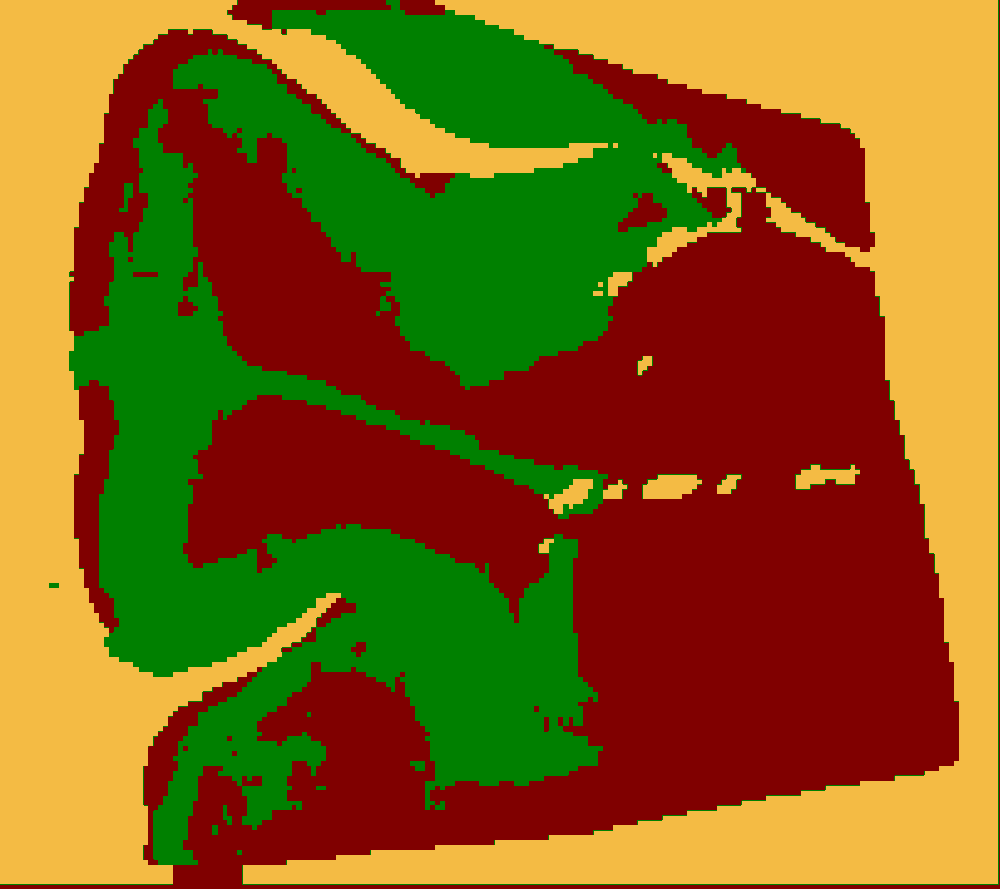

In [22]:
Image.fromarray(masked_image_3d.astype(np.uint8))

In [24]:
orig_img, orig_img_np=visualize_downscaled_original_image(img)

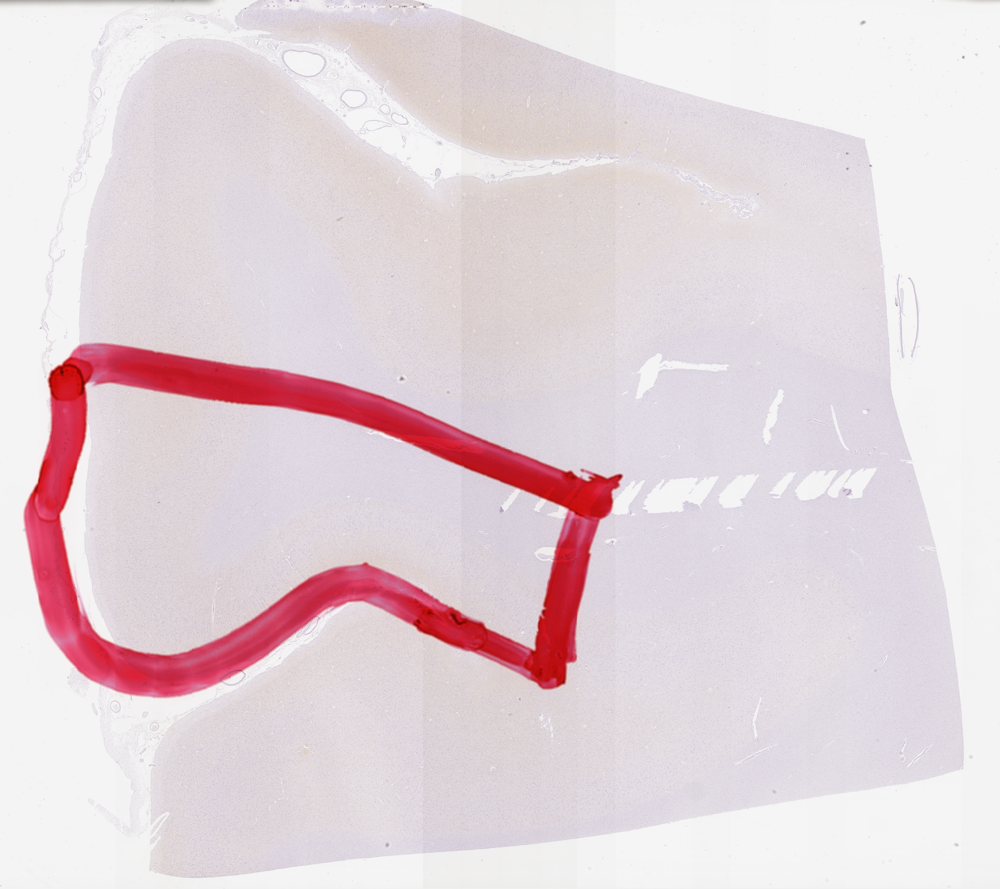

In [25]:
orig_img

## Ground Truth Mask

In [9]:
test_json_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_segmentation/test_wg/"
dlb_wsi_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases"
pdd_wsi_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases"
wsi_home_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/"

In [17]:
f_list = os.listdir(test_json_dir)
geofile = "PD088_Syn1_CG.svs.geojson"
#binary_array = generate_ground_truth_mask(test_json_dir,geofile,pdd_wsi_dir)
geofile = "11_063_CG_aSyn_x200.svs.geojson"
geofile = "19_053_TCx_aSyn_x200.svs.geojson"
geofile = '14_133_FCx_aSyn_x200.svs.geojson'
#geofile = "PD125_Syn1_PCx.svs.geojson"
geofile = "PD130_Syn1_EntCx.svs.geojson"
#binary_array = generate_ground_truth_mask(test_json_dir,geofile,dlb_wsi_dir)
binary_array = generate_ground_truth_mask(test_json_dir,geofile,pdd_wsi_dir)

White
White
grey
grey
grey
grey


## Batch Run

In [10]:
def run_segmentation(img):
    print(img,"---processing")
    masked_image = generate_mask_from_wgm_prediction(REF_IMG_PATH, img,stride, tilesize, BATCH_SIZE,WM_model_path,device)
    print("------- Mask Prediction Complete --------")
    geofile = img.split("/")[-1] + ".geojson"
    if geofile.startswith("PD"):
        binary_array = generate_ground_truth_mask(test_json_dir,geofile,pdd_wsi_dir)
    else:
        binary_array = generate_ground_truth_mask(test_json_dir,geofile,dlb_wsi_dir)
    print("-------- Ground truth mask complete --------")
    conf_final_np, eval_metrics  = wsi_seg_metric(device,masked_image,binary_array, geofile,eval_dir)
    print("-------- Evaluation done --------")
    path_2_save = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_segmentation/Image_Output/"+ img.split("/")[-1]
    if not os.path.exists(path_2_save):
        os.makedirs(path_2_save)
    masked_image_3d = visualize_downscaled_mask(masked_image)
    masked_image_3d1 = Image.fromarray(masked_image_3d.astype(np.uint8))
    masked_image_3d1.save(os.path.join(path_2_save,"mask.jpg"))
    orig_img, orig_img_np=visualize_downscaled_original_image(img)
    alpha = 0.9
    blended_img = blend_mask_with_orig(masked_image_3d,orig_img_np,alpha)
    orig_img.save(os.path.join(path_2_save,"original.jpg"))
    blended_img.save(os.path.join(path_2_save,"overlayed.jpg"))
    print("-------- Image saving done --------")
    

imgs = ['/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/14_133_FCx_aSyn_x200.svs',
        '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/19_053_TCx_aSyn_x200.svs',
        '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD125_Syn1_PCx.svs',
        "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD130_Syn1_EntCx.svs"]


for img in imgs[1:]:
    run_segmentation(img)
    #run_segmentation.cache_clear()

/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/19_053_TCx_aSyn_x200.svs ---processing
Init Normalization
------- Mask Prediction Complete --------


: 

: 

# Metrics

In [22]:

conf_final_np, eval_metrics  = wsi_seg_metric(device,masked_image,binary_array, geofile)

In [23]:
conf_final_np

array([[362920158,  63311548,  12517431],
       [ 70677744, 496600188,  29246204],
       [131246960,  63794376, 890027213]])

In [20]:
eval_metrics

,Class,Precision,recall,f1_score,iou_coeff
0,White,0.642513,0.82717,0.723241,0.566466
1,Grey,0.796209,0.83249,0.813945,0.686263
2,Background,0.955179,0.82025,0.882587,0.789849


## Overall Test Accuracy

In [28]:
from glob import glob
csv_files = glob(os.path.join("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_segmentation/Evaluation_Metrics/","*.csv"))
combined_df = pd.DataFrame()
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp["wsi_name"]= f.split("/")[-1]
    if len(combined_df)==0:
        combined_df=tmp
    else:
        combined_df=pd.concat([combined_df,tmp])    

In [31]:
combined_df.groupby(["Class"]).agg({"Precision":"mean","recall":"mean","f1_score":"mean","iou_coeff":"mean"})

,Precision,recall,f1_score,iou_coeff
Class,,,,
Background,0.960994,0.816291,0.876615,0.787465
Grey,0.868337,0.873587,0.868332,0.770890
White,0.715001,0.905881,0.798994,0.667710


: 

## Visualize Images